# 📈 Nelson-Siegel Yield Curve Modeling — BIRS

This notebook fits the **Nelson-Siegel (NS)** model to the Hungarian BIRS interest rate swap curve, then estimates a **Dynamic Nelson-Siegel (Diebold-Li)** model to study factor dynamics and produce forecasts.

## Model

The Nelson-Siegel model parameterizes the yield curve as:

$$y(\tau) = \beta_1 + \beta_2 \cdot \frac{1-e^{-\lambda\tau}}{\lambda\tau} + \beta_3 \cdot \left(\frac{1-e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau}\right)$$

where:
- $\beta_1$ — **Level** (long-run rate, asymptote as $\tau \to \infty$)
- $\beta_2$ — **Slope** (short-end vs. long-end; negative = upward-sloping)
- $\beta_3$ — **Curvature** (hump/trough in the medium tenors)
- $\lambda$ — **Decay** (controls where curvature peaks)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize, least_squares
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Load data
df = pd.read_pickle('birs_flat.pkl')
df['date of fixing'] = pd.to_datetime(df['date of fixing'])
df = df.sort_values('date of fixing').reset_index(drop=True)

# Tenor columns and numeric maturities (in years)
tenor_cols = [c for c in df.columns if 'years' in c]
tenor_cols.sort(key=lambda x: int(x.split()[0]))
maturities = np.array([int(c.split()[0]) for c in tenor_cols])

print(f"Data: {len(df):,} days, {df['date of fixing'].min().date()} → {df['date of fixing'].max().date()}")
print(f"Tenors: {maturities} years")
print(f"Columns: {tenor_cols}")

Data: 4,940 days, 2006-11-15 → 2026-06-08
Tenors: [ 2  3  4  5  6  7  8  9 10 12 15 20] years
Columns: ['2 years', '3 years', '4 years', '5 years', '6 years', '7 years', '8 years', '9 years', '10 years', '12 years', '15 years', '20 years']


## 1. Nelson-Siegel Model Definition

In [2]:
def ns_factor_loadings(tau, lam):
    """Compute the NS factor loadings for given maturities and lambda."""
    lt = lam * tau
    # Avoid division by zero
    lt = np.maximum(lt, 1e-10)
    exp_lt = np.exp(-lt)
    loading1 = np.ones_like(tau, dtype=float)                    # Level
    loading2 = (1 - exp_lt) / lt                                  # Slope
    loading3 = loading2 - exp_lt                                  # Curvature
    return loading1, loading2, loading3


def ns_curve(tau, beta1, beta2, beta3, lam):
    """Compute NS yield curve at given maturities."""
    L1, L2, L3 = ns_factor_loadings(tau, lam)
    return beta1 * L1 + beta2 * L2 + beta3 * L3


def fit_ns_ols(yields, tau, lam):
    """Fit NS model via OLS for a fixed lambda. Returns (beta1, beta2, beta3, residuals)."""
    L1, L2, L3 = ns_factor_loadings(tau, lam)
    X = np.column_stack([L1, L2, L3])
    # OLS: beta = (X'X)^{-1} X'y
    betas, residuals_sum, _, _ = np.linalg.lstsq(X, yields, rcond=None)
    fitted = X @ betas
    residuals = yields - fitted
    return betas, residuals, fitted


def fit_ns_full(yields, tau, lam0=0.5):
    """Fit NS model optimizing all parameters including lambda."""
    def objective(params):
        beta1, beta2, beta3, lam = params
        if lam <= 0.01 or lam > 5.0:
            return 1e10
        pred = ns_curve(tau, beta1, beta2, beta3, lam)
        return np.sum((yields - pred) ** 2)

    # Initial guess using OLS with fixed lambda
    betas0, _, _ = fit_ns_ols(yields, tau, lam0)
    x0 = [betas0[0], betas0[1], betas0[2], lam0]

    result = minimize(objective, x0, method='Nelder-Mead',
                      options={'maxiter': 5000, 'xatol': 1e-8, 'fatol': 1e-10})
    beta1, beta2, beta3, lam = result.x
    fitted = ns_curve(tau, beta1, beta2, beta3, lam)
    residuals = yields - fitted
    return np.array([beta1, beta2, beta3]), lam, residuals, fitted


print("NS functions defined.")
print("\nFactor loading interpretation:")
print("  β₁ loading → 1 for all τ (level)")
print("  β₂ loading → starts at 1, decays to 0 (slope)")
print("  β₃ loading → starts at 0, humps, decays to 0 (curvature)")

NS functions defined.

Factor loading interpretation:
  β₁ loading → 1 for all τ (level)
  β₂ loading → starts at 1, decays to 0 (slope)
  β₃ loading → starts at 0, humps, decays to 0 (curvature)


## 2. Factor Loadings Visualization

How do the NS factor loadings behave across maturities?

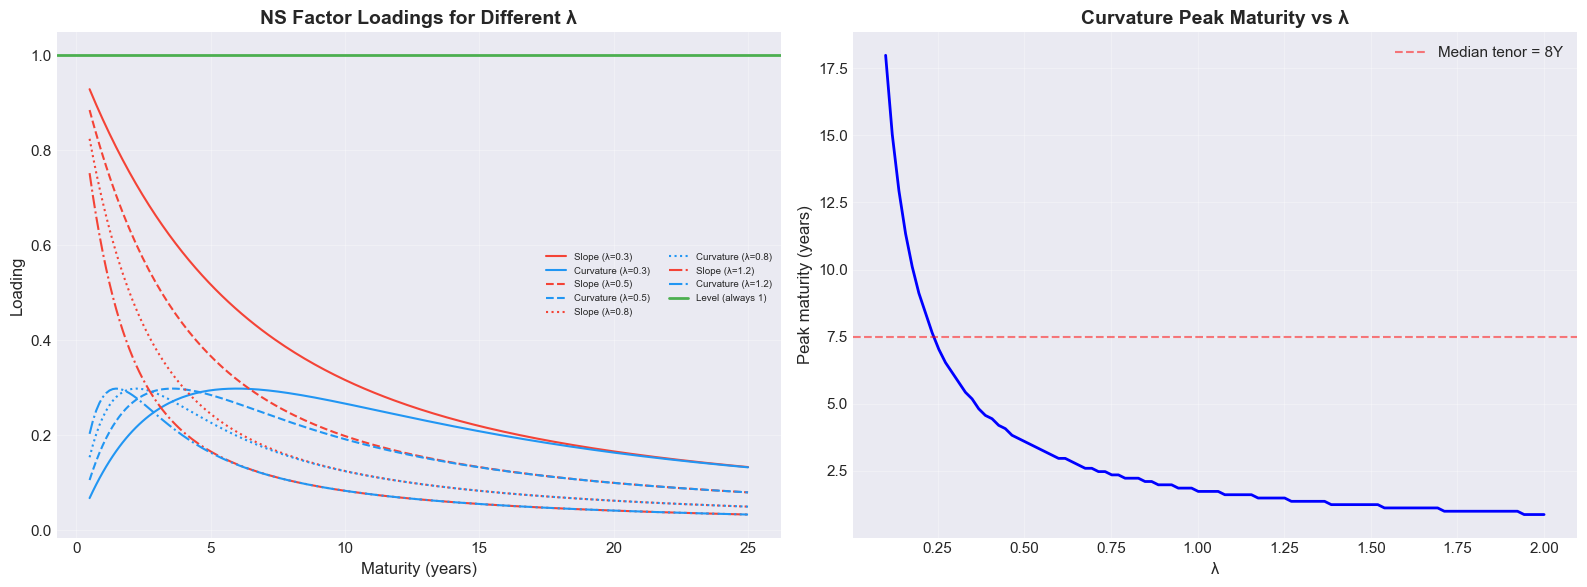

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: loadings for different lambdas
tau_fine = np.linspace(0.5, 25, 200)
for lam, ls in [(0.3, '-'), (0.5, '--'), (0.8, ':'), (1.2, '-.')]:
    L1, L2, L3 = ns_factor_loadings(tau_fine, lam)
    axes[0].plot(tau_fine, L2, ls, color='#F44336', linewidth=1.5, label=f'Slope (λ={lam})')
    axes[0].plot(tau_fine, L3, ls, color='#2196F3', linewidth=1.5, label=f'Curvature (λ={lam})')

axes[0].axhline(y=1, color='#4CAF50', linewidth=2, label='Level (always 1)')
axes[0].set_title('NS Factor Loadings for Different λ', fontweight='bold')
axes[0].set_xlabel('Maturity (years)')
axes[0].set_ylabel('Loading')
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)

# Right: curvature peak location vs lambda
lambdas = np.linspace(0.1, 2.0, 100)
peaks = []
for lam in lambdas:
    _, _, L3 = ns_factor_loadings(tau_fine, lam)
    peak_tau = tau_fine[np.argmax(L3)]
    peaks.append(peak_tau)

axes[1].plot(lambdas, peaks, 'b-', linewidth=2)
axes[1].axhline(y=np.median(maturities), color='red', linestyle='--', alpha=0.5,
                label=f'Median tenor = {np.median(maturities):.0f}Y')
axes[1].set_title('Curvature Peak Maturity vs λ', fontweight='bold')
axes[1].set_xlabel('λ')
axes[1].set_ylabel('Peak maturity (years)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Optimal Lambda Selection

We find the λ that minimizes the average fitting error across all days. This follows the Diebold-Li approach of fixing λ for the entire sample.

Days with ≥5 valid tenors: 4,940 / 4,940



Optimal λ = 0.3709
Min RMSE  = 0.0579 pp


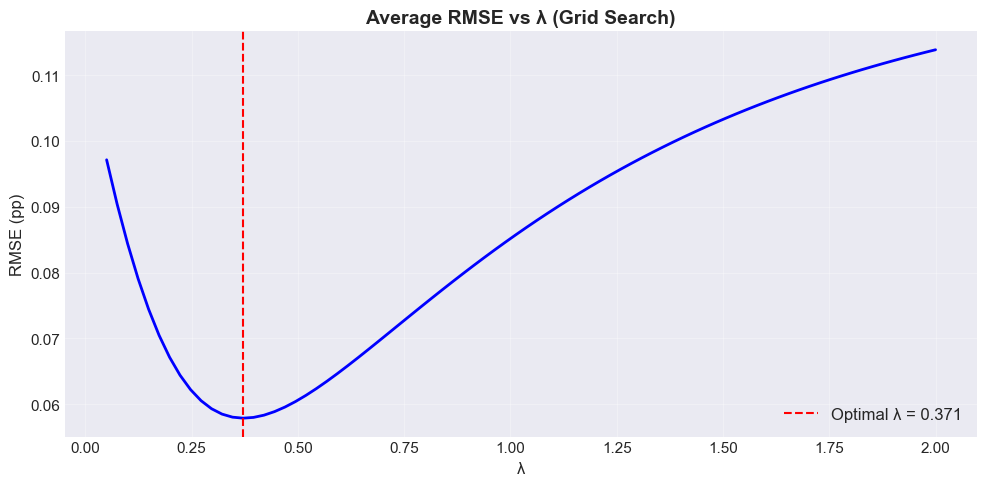

In [4]:
# Prepare the yield matrix (each row = one day)
yield_matrix = df[tenor_cols].values
dates = df['date of fixing'].values

# Mask for rows with enough data (at least 5 tenors)
valid_mask = np.sum(~np.isnan(yield_matrix), axis=1) >= 5
print(f"Days with ≥5 valid tenors: {valid_mask.sum():,} / {len(df):,}")

# Grid search for optimal fixed lambda
lambda_grid = np.linspace(0.05, 2.0, 80)
avg_rmse = []

for lam in lambda_grid:
    total_sse = 0
    n_obs = 0
    for i in np.where(valid_mask)[0][::10]:  # Sample every 10th day for speed
        y = yield_matrix[i]
        valid = ~np.isnan(y)
        if valid.sum() < 3:
            continue
        tau_v = maturities[valid].astype(float)
        y_v = y[valid]
        betas, resid, _ = fit_ns_ols(y_v, tau_v, lam)
        total_sse += np.sum(resid ** 2)
        n_obs += len(y_v)
    avg_rmse.append(np.sqrt(total_sse / max(n_obs, 1)))

optimal_lambda = lambda_grid[np.argmin(avg_rmse)]
print(f"\nOptimal λ = {optimal_lambda:.4f}")
print(f"Min RMSE  = {min(avg_rmse):.4f} pp")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lambda_grid, avg_rmse, 'b-', linewidth=2)
ax.axvline(x=optimal_lambda, color='red', linestyle='--', linewidth=1.5,
           label=f'Optimal λ = {optimal_lambda:.3f}')
ax.set_title('Average RMSE vs λ (Grid Search)', fontweight='bold')
ax.set_xlabel('λ')
ax.set_ylabel('RMSE (pp)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Daily Cross-Sectional Fitting

Fit the NS model to every trading day using the optimal λ.

In [5]:
# Fit NS to every day
LAM = optimal_lambda

results = []
for i in range(len(df)):
    y = yield_matrix[i]
    valid = ~np.isnan(y)
    if valid.sum() < 3:
        results.append([np.nan, np.nan, np.nan, np.nan])
        continue

    tau_v = maturities[valid].astype(float)
    y_v = y[valid]
    betas, resid, fitted = fit_ns_ols(y_v, tau_v, LAM)
    rmse = np.sqrt(np.mean(resid ** 2))
    results.append([betas[0], betas[1], betas[2], rmse])

results = np.array(results)
factors = pd.DataFrame({
    'date': df['date of fixing'],
    'beta1_level': results[:, 0],
    'beta2_slope': results[:, 1],
    'beta3_curvature': results[:, 2],
    'rmse': results[:, 3],
})
factors = factors.dropna().reset_index(drop=True)

print(f"Successfully fitted {len(factors):,} days")
print(f"\nFactor statistics:")
print(factors[['beta1_level', 'beta2_slope', 'beta3_curvature', 'rmse']].describe().round(4).to_string())

Successfully fitted 4,940 days

Factor statistics:
       beta1_level  beta2_slope  beta3_curvature       rmse
count    4940.0000    4940.0000        4940.0000  4940.0000
mean        5.5967      -0.6266          -1.5101     0.0467
std         1.6039       3.1648           3.2472     0.0366
min         2.0748      -5.0436         -12.0616     0.0028
25%         4.1877      -2.7829          -2.9730     0.0172
50%         5.9948      -1.1610          -1.4158     0.0370
75%         6.7960       0.7889           0.8875     0.0675
max        10.6007      12.7616           6.1597     0.7755


## 5. NS Factor Time Series

The three Nelson-Siegel factors capture the evolution of the yield curve over time.

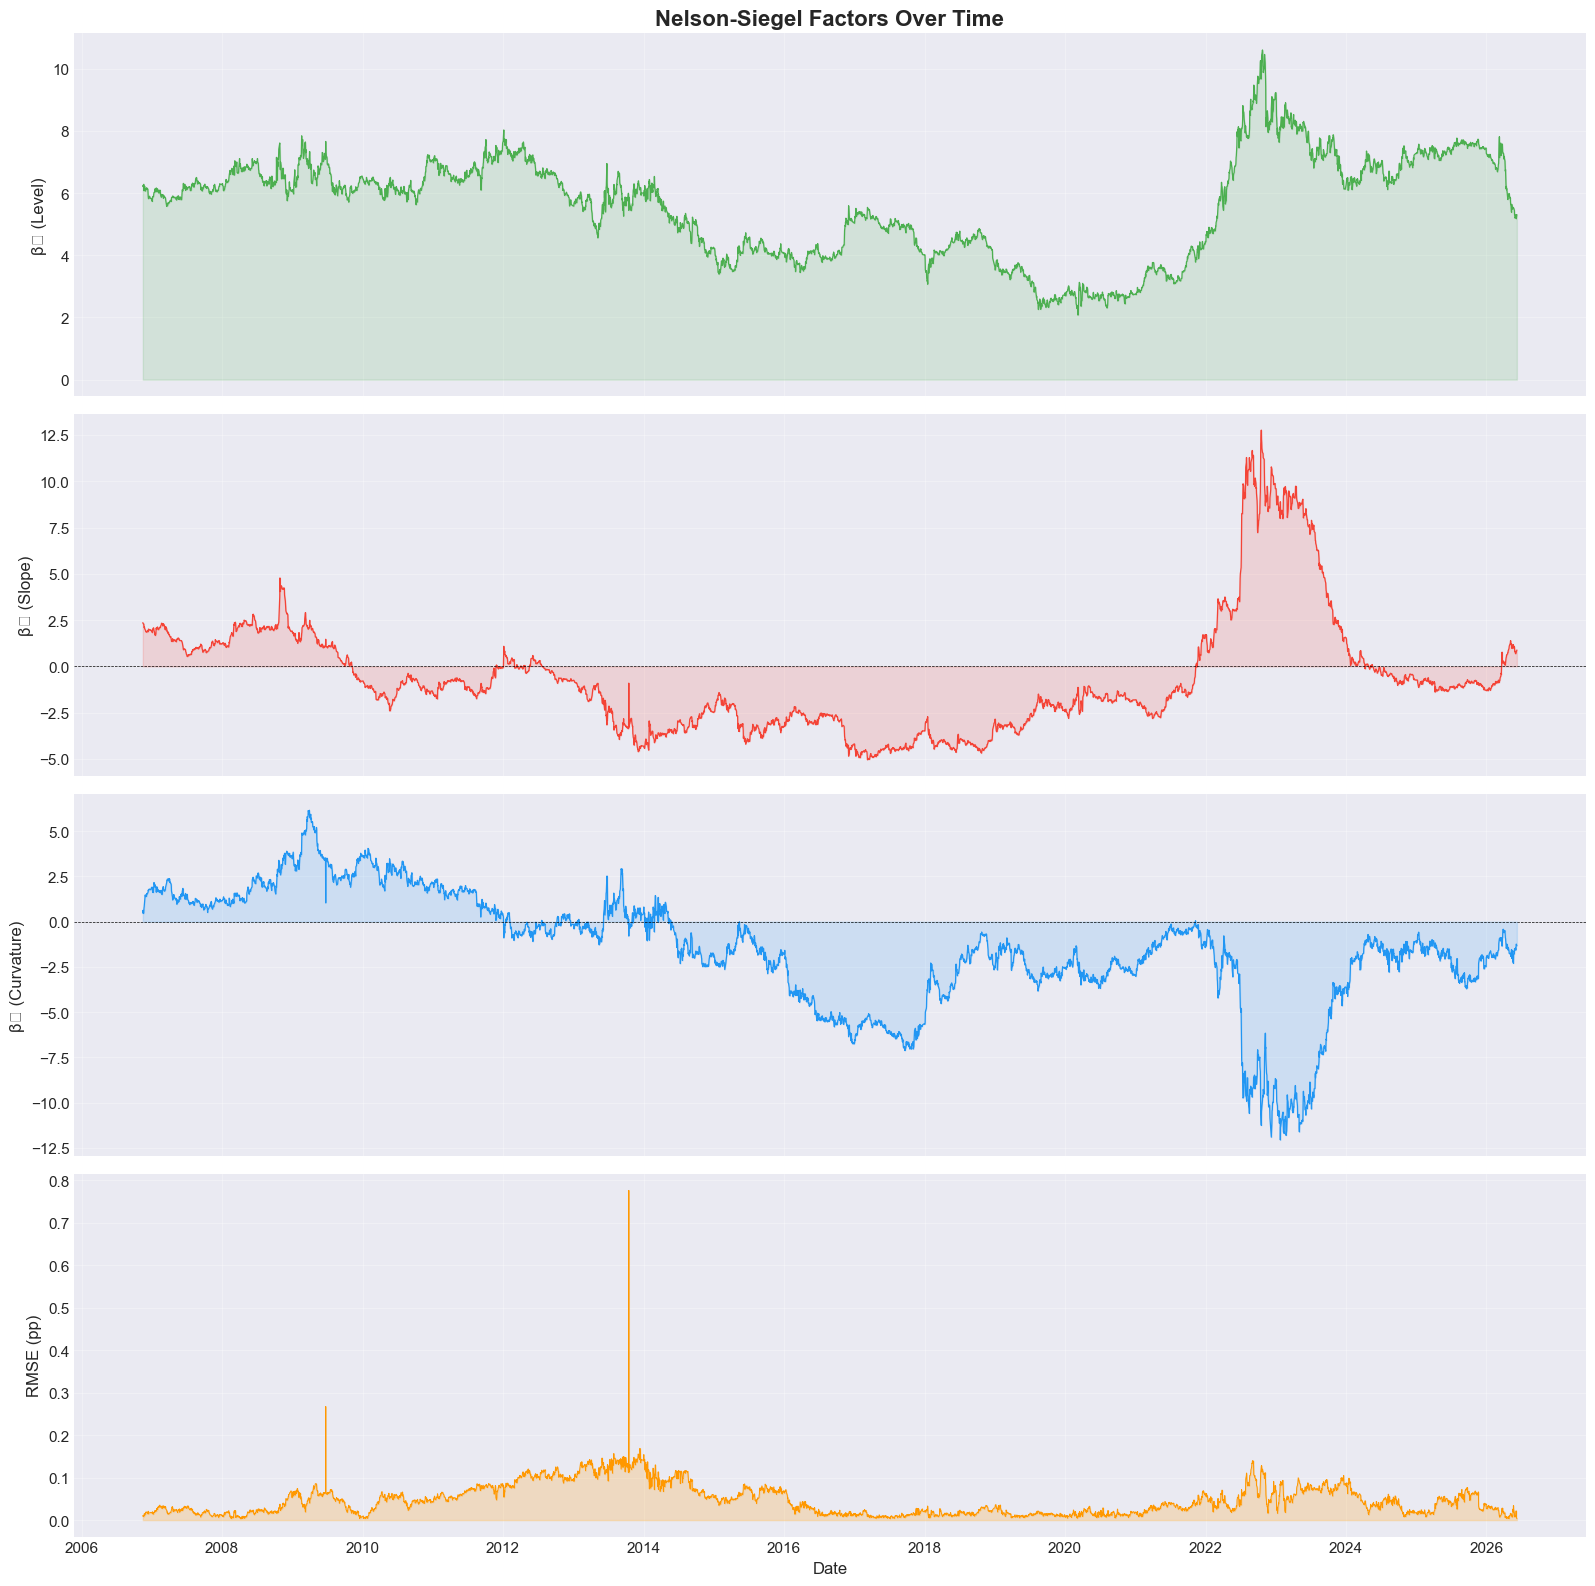

Average RMSE: 0.0467 pp
Median RMSE:  0.0370 pp
95th pctl:    0.1171 pp


In [6]:
fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

# β₁ — Level
axes[0].plot(factors['date'], factors['beta1_level'], color='#4CAF50', linewidth=0.9)
axes[0].set_ylabel('β₁ (Level)')
axes[0].set_title('Nelson-Siegel Factors Over Time', fontweight='bold', fontsize=16)
axes[0].fill_between(factors['date'], factors['beta1_level'],
                     alpha=0.15, color='#4CAF50')
axes[0].grid(True, alpha=0.3)

# β₂ — Slope
axes[1].plot(factors['date'], factors['beta2_slope'], color='#F44336', linewidth=0.9)
axes[1].axhline(y=0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('β₂ (Slope)')
axes[1].fill_between(factors['date'], factors['beta2_slope'],
                     alpha=0.15, color='#F44336')
axes[1].grid(True, alpha=0.3)

# β₃ — Curvature
axes[2].plot(factors['date'], factors['beta3_curvature'], color='#2196F3', linewidth=0.9)
axes[2].axhline(y=0, color='black', linewidth=0.5, linestyle='--')
axes[2].set_ylabel('β₃ (Curvature)')
axes[2].fill_between(factors['date'], factors['beta3_curvature'],
                     alpha=0.15, color='#2196F3')
axes[2].grid(True, alpha=0.3)

# RMSE — Fit quality
axes[3].plot(factors['date'], factors['rmse'], color='#FF9800', linewidth=0.7)
axes[3].set_ylabel('RMSE (pp)')
axes[3].set_xlabel('Date')
axes[3].fill_between(factors['date'], factors['rmse'],
                     alpha=0.2, color='#FF9800')
axes[3].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print(f"Average RMSE: {factors['rmse'].mean():.4f} pp")
print(f"Median RMSE:  {factors['rmse'].median():.4f} pp")
print(f"95th pctl:    {factors['rmse'].quantile(0.95):.4f} pp")

## 6. Goodness of Fit

How well does the NS model reproduce the actual BIRS curve?

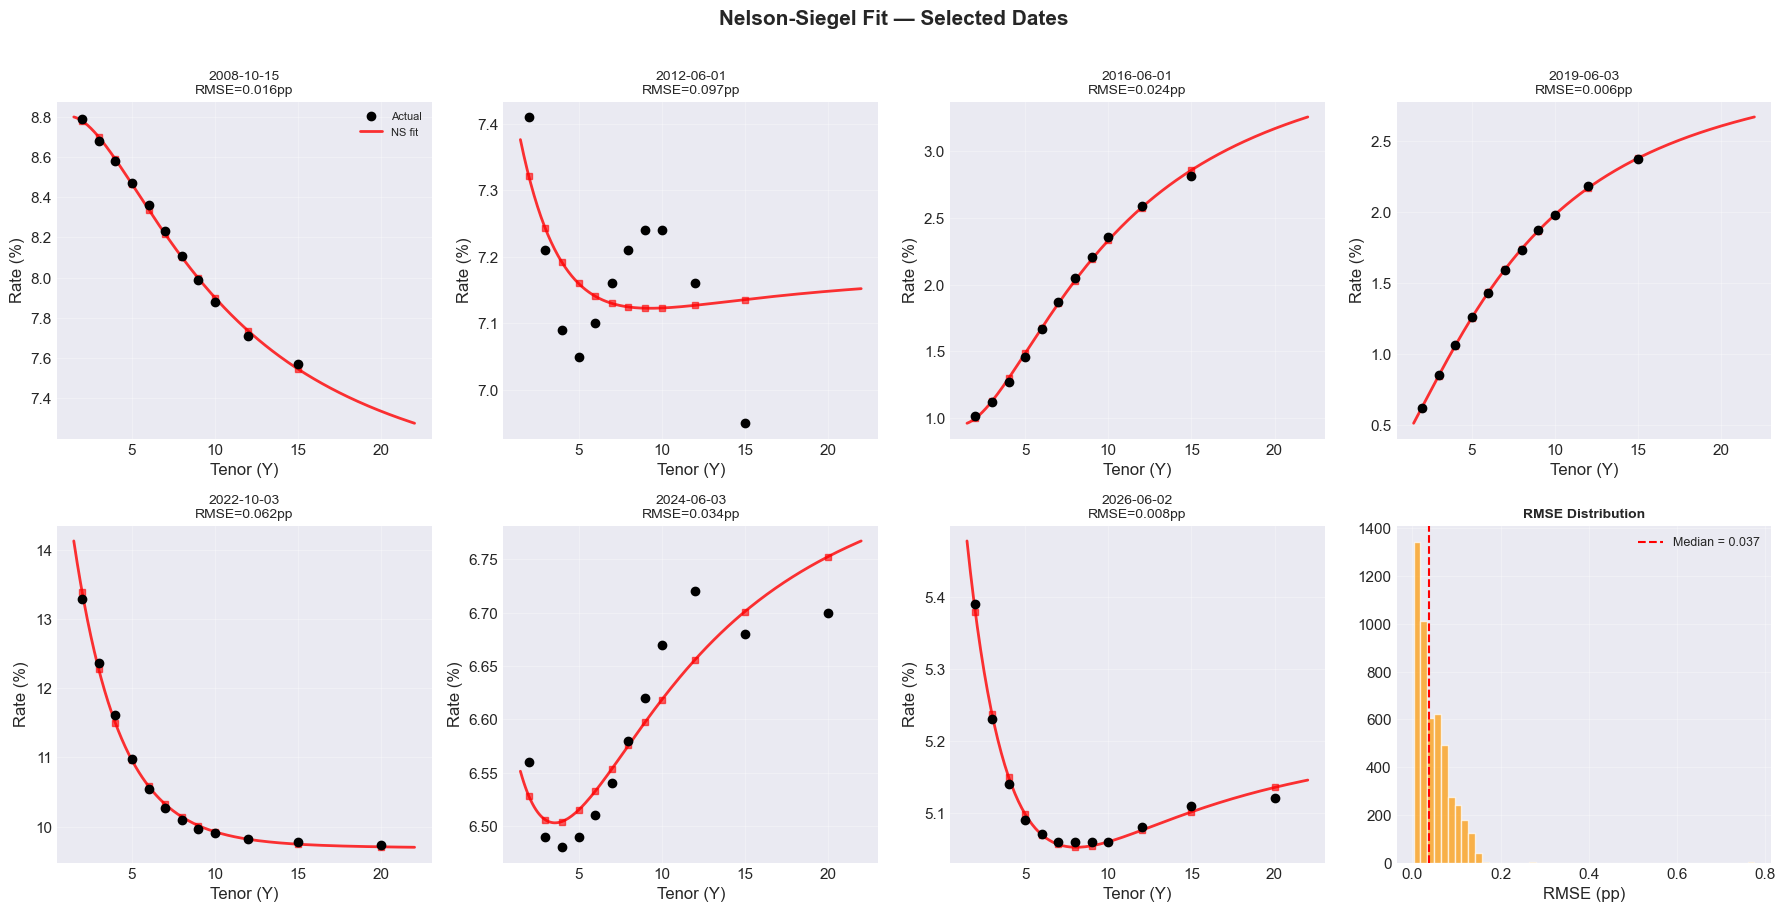

In [7]:
# Show fitted vs actual for selected dates
sample_dates = ['2008-10-15', '2012-06-01', '2016-06-01',
                '2019-06-03', '2022-10-03', '2024-06-03', '2026-06-02']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

tau_fine = np.linspace(1.5, 22, 200)

for idx, date_str in enumerate(sample_dates):
    ax = axes[idx]
    target = pd.Timestamp(date_str)
    row_idx = (df['date of fixing'] - target).abs().idxmin()
    actual_date = df.loc[row_idx, 'date of fixing']

    y = yield_matrix[row_idx]
    valid = ~np.isnan(y)
    tau_v = maturities[valid].astype(float)
    y_v = y[valid]

    betas, resid, fitted = fit_ns_ols(y_v, tau_v, LAM)
    rmse = np.sqrt(np.mean(resid ** 2))

    # Fitted curve (smooth)
    y_smooth = ns_curve(tau_fine, betas[0], betas[1], betas[2], LAM)

    ax.plot(tau_v, y_v, 'ko', markersize=6, label='Actual', zorder=5)
    ax.plot(tau_fine, y_smooth, 'r-', linewidth=2, label='NS fit', alpha=0.8)
    ax.plot(tau_v, fitted, 'rs', markersize=4, alpha=0.6)
    ax.set_title(f"{actual_date.strftime('%Y-%m-%d')}\nRMSE={rmse:.3f}pp", fontsize=10)
    ax.set_xlabel('Tenor (Y)')
    ax.set_ylabel('Rate (%)')
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8)

# Empty last subplot — put RMSE distribution
ax = axes[7]
ax.hist(factors['rmse'], bins=50, color='#FF9800', alpha=0.7, edgecolor='white')
ax.axvline(factors['rmse'].median(), color='red', linestyle='--',
           label=f"Median = {factors['rmse'].median():.3f}")
ax.set_title('RMSE Distribution', fontsize=10, fontweight='bold')
ax.set_xlabel('RMSE (pp)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Nelson-Siegel Fit — Selected Dates', fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

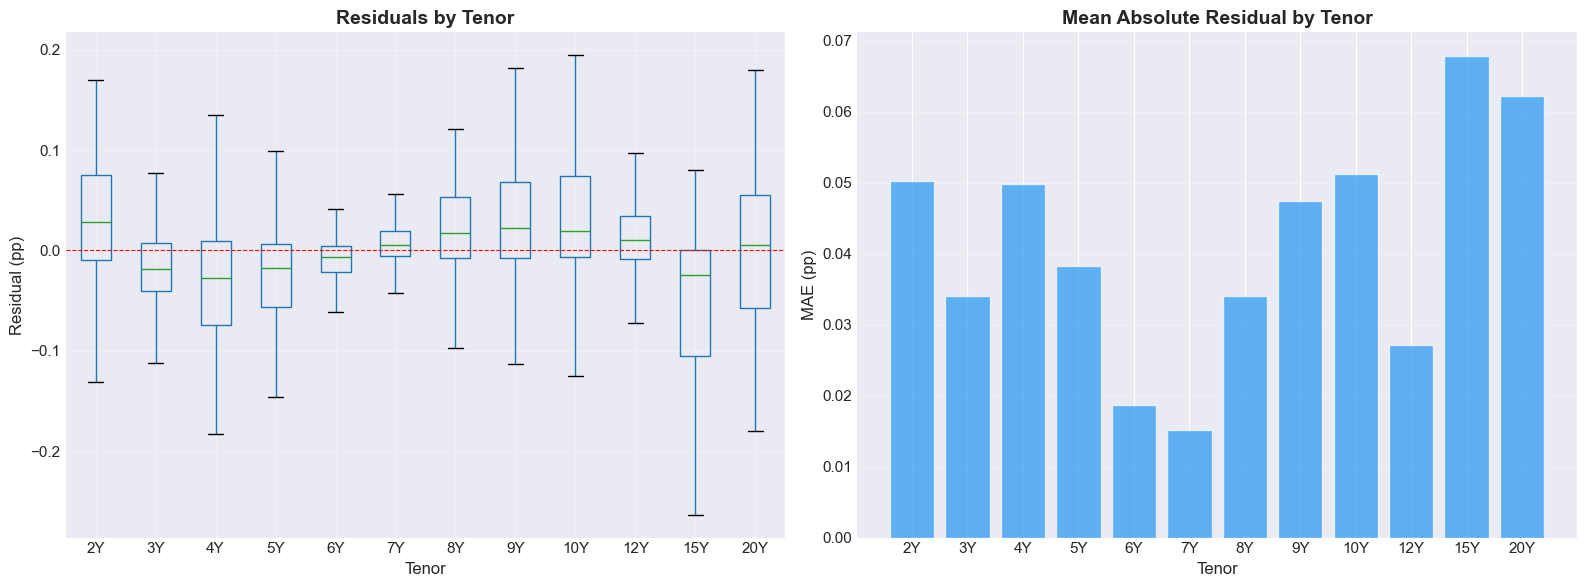

Mean Absolute Error by tenor:
  2Y: 0.0502 pp
  3Y: 0.0340 pp
  4Y: 0.0498 pp
  5Y: 0.0383 pp
  6Y: 0.0187 pp
  7Y: 0.0152 pp
  8Y: 0.0340 pp
  9Y: 0.0474 pp
  10Y: 0.0513 pp
  12Y: 0.0271 pp
  15Y: 0.0678 pp
  20Y: 0.0622 pp


In [8]:
# Residual analysis by tenor
all_residuals = {}
for i in range(len(df)):
    y = yield_matrix[i]
    valid = ~np.isnan(y)
    if valid.sum() < 3:
        continue
    tau_v = maturities[valid].astype(float)
    y_v = y[valid]
    betas, resid, _ = fit_ns_ols(y_v, tau_v, LAM)
    for j, (t, r) in enumerate(zip(maturities[valid], resid)):
        col_name = f'{t}Y'
        if col_name not in all_residuals:
            all_residuals[col_name] = []
        all_residuals[col_name].append(r)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot of residuals by tenor
resid_df = pd.DataFrame({k: pd.Series(v) for k, v in all_residuals.items()})
tenor_order = sorted(resid_df.columns, key=lambda x: int(x.replace('Y', '')))
resid_df[tenor_order].boxplot(ax=axes[0], showfliers=False)
axes[0].axhline(y=0, color='red', linewidth=0.8, linestyle='--')
axes[0].set_title('Residuals by Tenor', fontweight='bold')
axes[0].set_xlabel('Tenor')
axes[0].set_ylabel('Residual (pp)')
axes[0].grid(True, alpha=0.3)

# Mean absolute residual by tenor
mae_by_tenor = resid_df[tenor_order].abs().mean()
axes[1].bar(tenor_order, mae_by_tenor, color='#2196F3', alpha=0.7, edgecolor='white')
axes[1].set_title('Mean Absolute Residual by Tenor', fontweight='bold')
axes[1].set_xlabel('Tenor')
axes[1].set_ylabel('MAE (pp)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Mean Absolute Error by tenor:")
for t in tenor_order:
    print(f"  {t}: {resid_df[t].abs().mean():.4f} pp")

## 7. Factor Dynamics — Diebold-Li VAR(1) Model

The Dynamic Nelson-Siegel model (Diebold & Li, 2006) models the factor evolution as a **VAR(1)**:

$$\begin{pmatrix} \beta_{1,t} \\ \beta_{2,t} \\ \beta_{3,t} \end{pmatrix} = \mathbf{c} + \mathbf{A} \begin{pmatrix} \beta_{1,t-1} \\ \beta_{2,t-1} \\ \beta_{3,t-1} \end{pmatrix} + \boldsymbol{\varepsilon}_t$$

This captures mean-reversion and cross-factor dynamics.

In [9]:
# Prepare factor data for VAR estimation
factor_data = factors[['date', 'beta1_level', 'beta2_slope', 'beta3_curvature']].copy()
factor_data = factor_data.set_index('date')

# Estimate VAR(1) via OLS
Y = factor_data.values[1:]         # (T-1, 3)
X = factor_data.values[:-1]        # (T-1, 3) lagged
X_with_const = np.column_stack([np.ones(len(X)), X])  # add intercept

# OLS: Y = X_aug @ [c; A]'
coeffs = np.linalg.lstsq(X_with_const, Y, rcond=None)[0]
c_vec = coeffs[0]        # (3,) intercept
A_mat = coeffs[1:]       # (3,3) transition matrix

# Residuals and covariance
residuals = Y - X_with_const @ coeffs
sigma = np.cov(residuals.T)

print("VAR(1) Estimation Results")
print("=" * 50)
print(f"\nIntercept vector c:")
for name, val in zip(['β₁', 'β₂', 'β₃'], c_vec):
    print(f"  {name}: {val:+.6f}")

print(f"\nTransition matrix A:")
names = ['β₁', 'β₂', 'β₃']
header = "      " + "   ".join(f"{n:>8s}" for n in names)
print(header)
for i, name in enumerate(names):
    row = "   ".join(f"{A_mat[j, i]:+.6f}" for j in range(3))
    print(f"  {name}:  {row}")

print(f"\nEigenvalues of A: {np.linalg.eigvals(A_mat).round(4)}")
print(f"(All < 1 → stationary: {all(np.abs(np.linalg.eigvals(A_mat)) < 1)})")

# Implied long-run means: (I - A)^{-1} c
I = np.eye(3)
long_run = np.linalg.solve(I - A_mat.T, c_vec)
print(f"\nLong-run (unconditional) means:")
for name, val in zip(names, long_run):
    print(f"  {name}: {val:.4f}")

# Half-lives
eigenvals = np.linalg.eigvals(A_mat)
half_lives = -np.log(2) / np.log(np.abs(eigenvals))
print(f"\nImplied half-lives: {half_lives.round(1)} days")

VAR(1) Estimation Results

Intercept vector c:
  β₁: +0.025493
  β₂: -0.014920
  β₃: -0.007624

Transition matrix A:
            β₁         β₂         β₃
  β₁:  +0.995741   +0.001780   +0.000483
  β₂:  +0.002394   +0.998275   -0.000092
  β₃:  +0.000739   +0.000003   +0.997933

Eigenvalues of A: [0.9945 0.9995 0.998 ]
(All < 1 → stationary: True)

Long-run (unconditional) means:
  β₁: 5.2538
  β₂: -1.2602
  β₃: -1.8126

Implied half-lives: [ 125.7 1310.8  342.5] days


## 8. VAR(1) In-Sample Fit

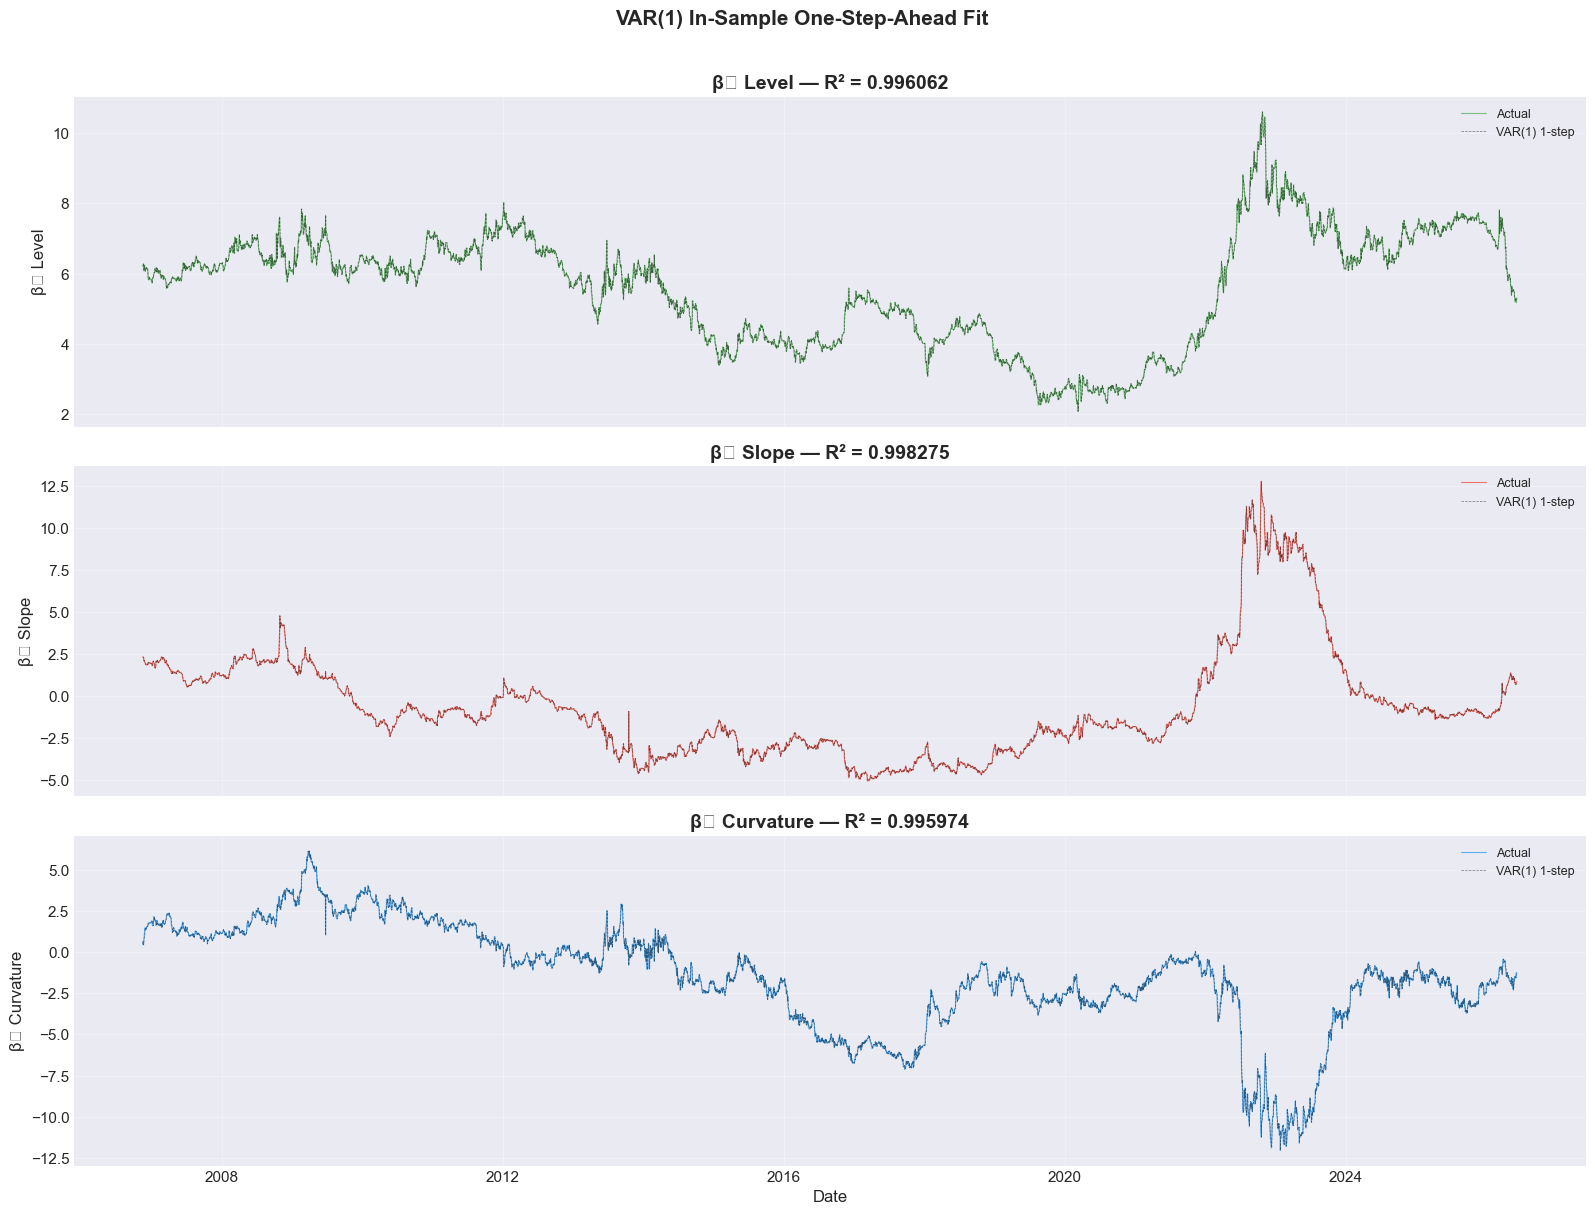

In [10]:
# One-step-ahead predictions
predicted = X_with_const @ coeffs
dates_var = factor_data.index[1:]

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
factor_names = ['β₁ Level', 'β₂ Slope', 'β₃ Curvature']
colors = ['#4CAF50', '#F44336', '#2196F3']

for i, (name, color) in enumerate(zip(factor_names, colors)):
    axes[i].plot(dates_var, Y[:, i], color=color, linewidth=0.8, alpha=0.7, label='Actual')
    axes[i].plot(dates_var, predicted[:, i], color='black', linewidth=0.5,
                 alpha=0.5, linestyle='--', label='VAR(1) 1-step')
    axes[i].set_ylabel(name)
    axes[i].legend(fontsize=9, loc='upper right')
    axes[i].grid(True, alpha=0.3)
    # R-squared
    ss_res = np.sum((Y[:, i] - predicted[:, i]) ** 2)
    ss_tot = np.sum((Y[:, i] - np.mean(Y[:, i])) ** 2)
    r2 = 1 - ss_res / ss_tot
    axes[i].set_title(f'{name} — R² = {r2:.6f}', fontweight='bold')

axes[-1].set_xlabel('Date')
plt.suptitle('VAR(1) In-Sample One-Step-Ahead Fit', fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 9. VAR Residual Diagnostics

β₁ Level: mean=-0.000000, std=0.1006, skew=-0.276, kurt=11.847, JB stat=28944.5 (p=0.00e+00)
β₂ Slope: mean=0.000000, std=0.1314, skew=1.371, kurt=65.728, JB stat=890601.2 (p=0.00e+00)
β₃ Curvature: mean=0.000000, std=0.2060, skew=-0.145, kurt=13.037, JB stat=34992.6 (p=0.00e+00)


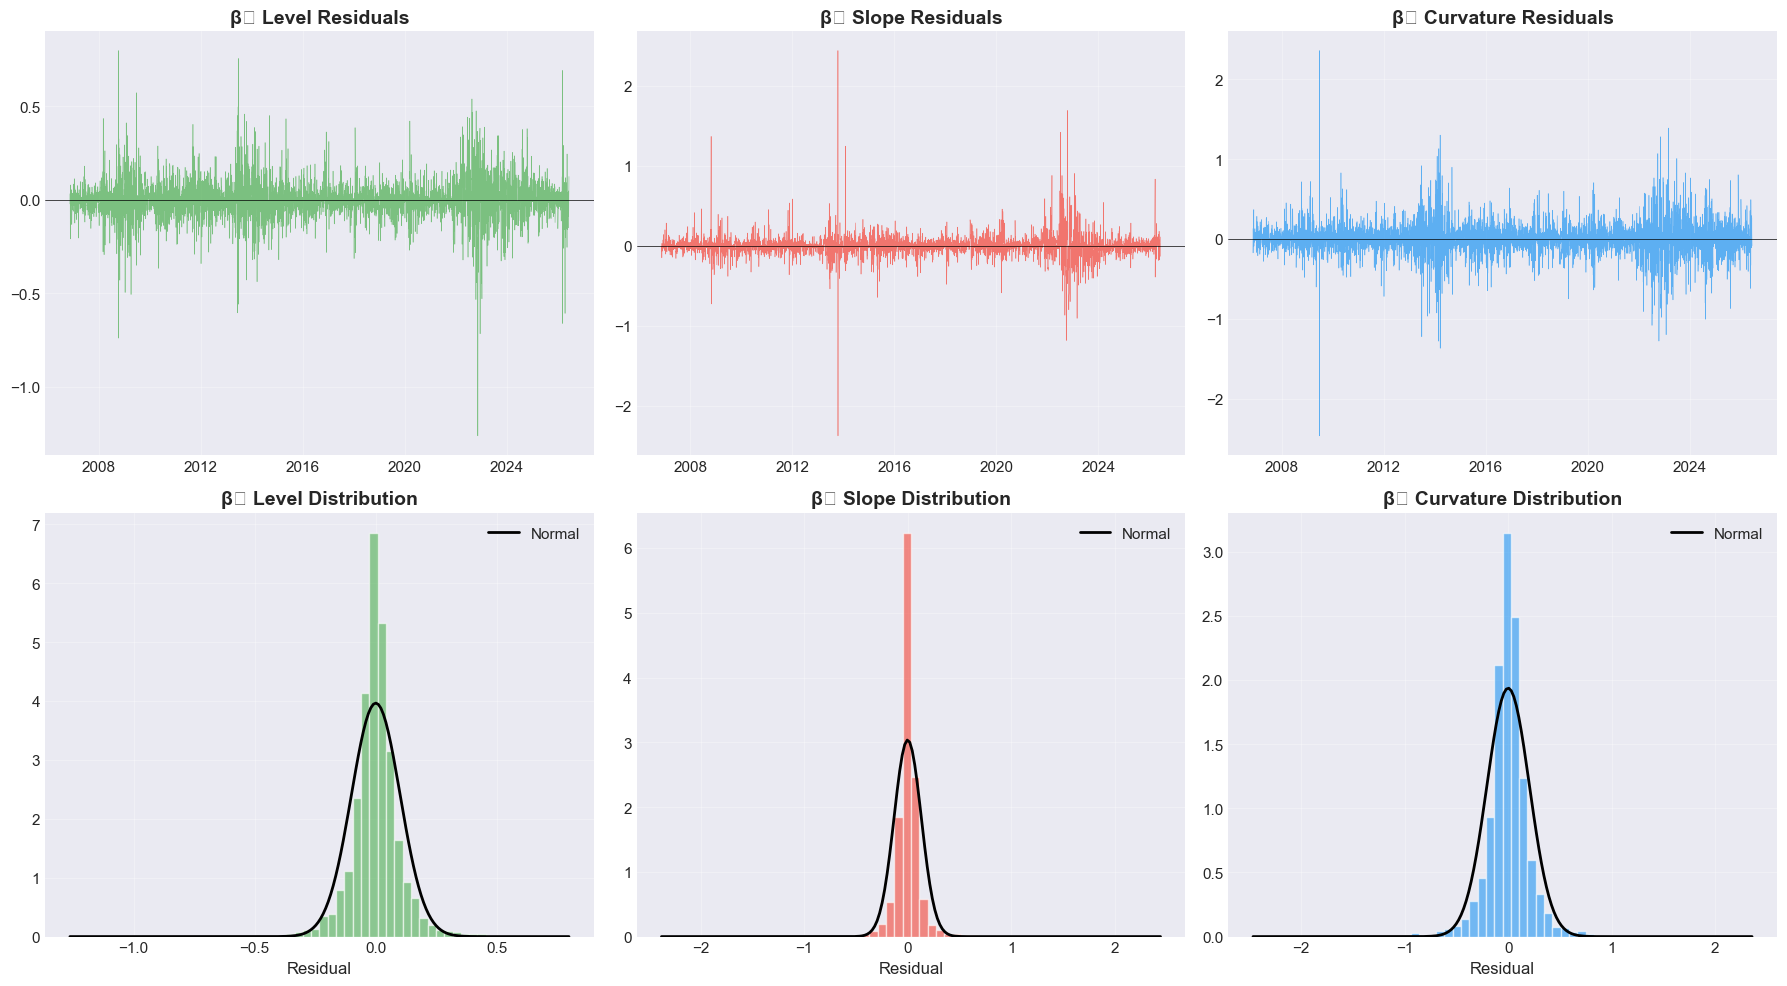


Residual correlation matrix:
  corr(β₁ Level, β₁ Level) = 1.0000
  corr(β₁ Level, β₂ Slope) = -0.2961
  corr(β₁ Level, β₃ Curvature) = -0.0809
  corr(β₂ Slope, β₂ Slope) = 1.0000
  corr(β₂ Slope, β₃ Curvature) = -0.4549
  corr(β₃ Curvature, β₃ Curvature) = 1.0000


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
factor_names = ['β₁ Level', 'β₂ Slope', 'β₃ Curvature']
colors = ['#4CAF50', '#F44336', '#2196F3']

for i, (name, color) in enumerate(zip(factor_names, colors)):
    # Top row: residual time series
    axes[0, i].plot(dates_var, residuals[:, i], color=color, linewidth=0.4, alpha=0.7)
    axes[0, i].set_title(f'{name} Residuals', fontweight='bold')
    axes[0, i].axhline(y=0, color='black', linewidth=0.5)
    axes[0, i].grid(True, alpha=0.3)

    # Bottom row: histogram + normal overlay
    data = residuals[:, i]
    axes[1, i].hist(data, bins=60, density=True, alpha=0.6, color=color, edgecolor='white')
    x_range = np.linspace(data.min(), data.max(), 200)
    axes[1, i].plot(x_range, norm.pdf(x_range, data.mean(), data.std()),
                    'k-', linewidth=2, label='Normal')
    axes[1, i].set_title(f'{name} Distribution', fontweight='bold')
    axes[1, i].set_xlabel('Residual')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

    # Stats
    from scipy.stats import jarque_bera, kurtosis, skew
    jb_stat, jb_p = jarque_bera(data)
    print(f"{name}: mean={data.mean():.6f}, std={data.std():.4f}, "
          f"skew={skew(data):.3f}, kurt={kurtosis(data):.3f}, "
          f"JB stat={jb_stat:.1f} (p={jb_p:.2e})")

plt.tight_layout()
plt.show()

# Residual correlation matrix
print("\nResidual correlation matrix:")
resid_corr = np.corrcoef(residuals.T)
for i, n1 in enumerate(factor_names):
    for j, n2 in enumerate(factor_names):
        if j >= i:
            print(f"  corr({n1}, {n2}) = {resid_corr[i,j]:.4f}")

## 10. Multi-Step Yield Curve Forecasts

Using the VAR(1) model to forecast the NS factors forward, then reconstruct the yield curve.

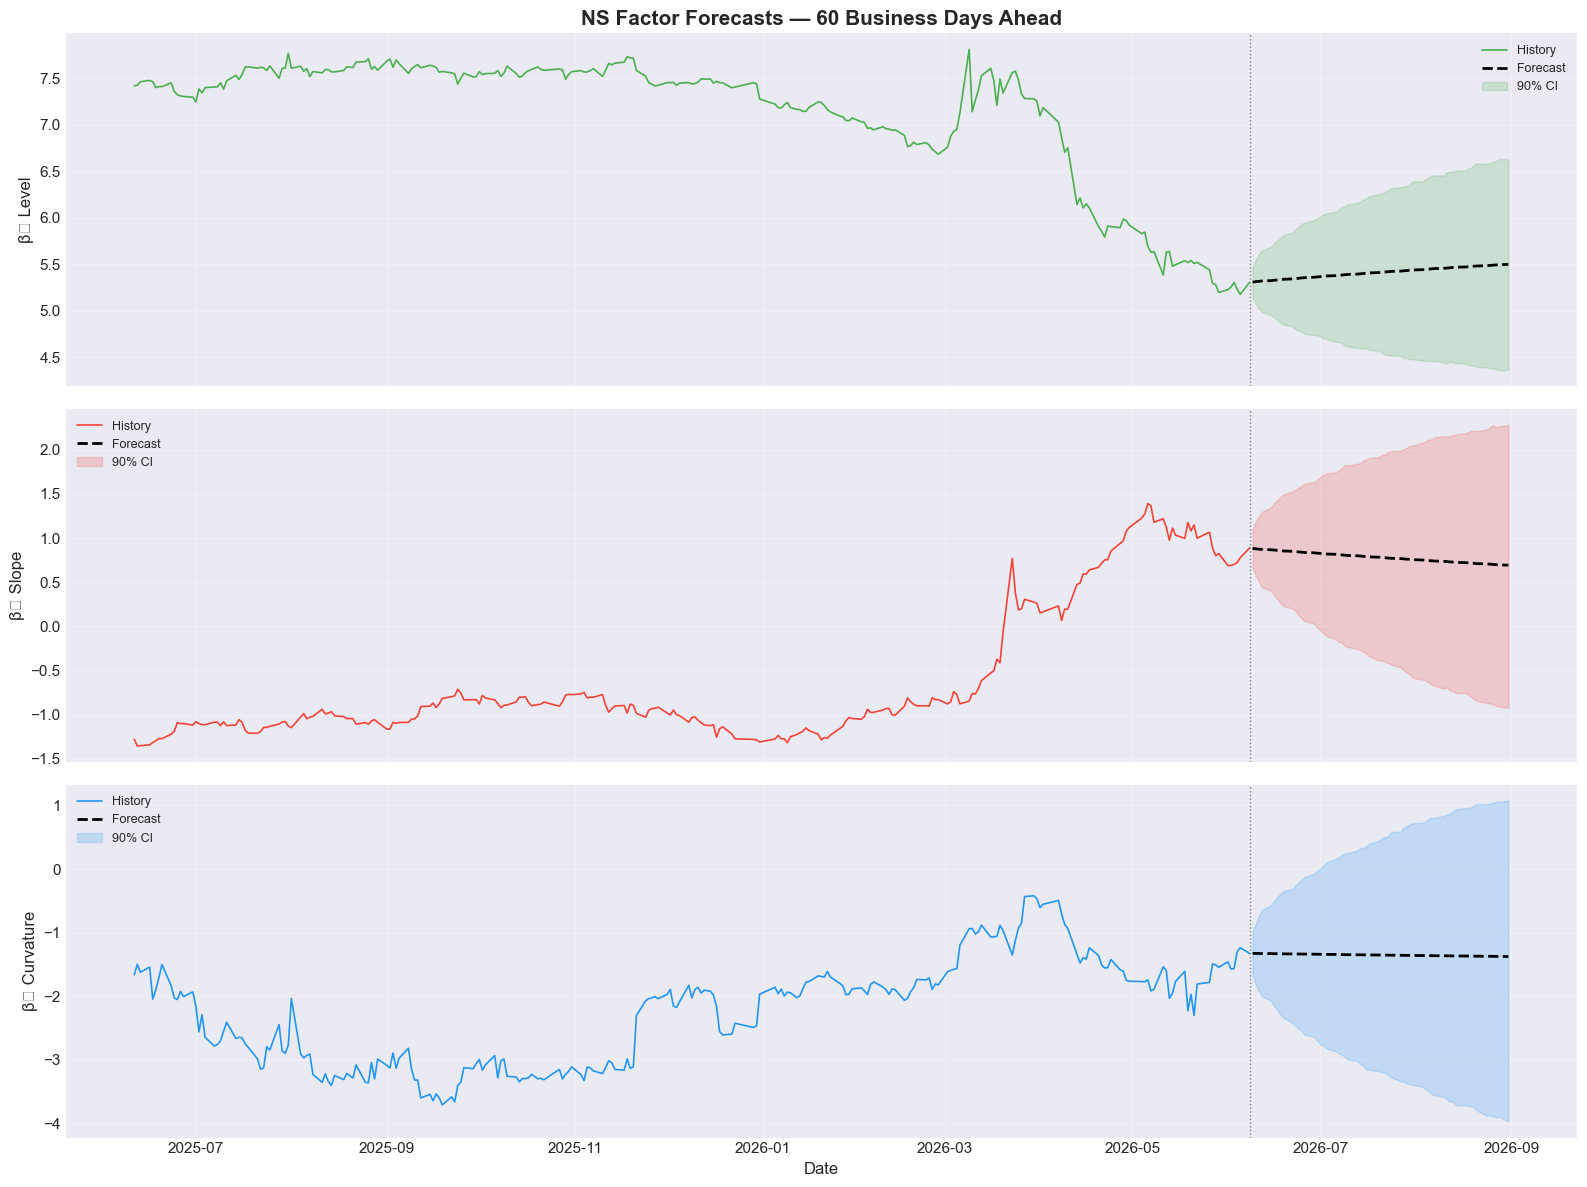

In [12]:
def forecast_ns_factors(last_factors, c, A, n_steps):
    """Iterate VAR(1) forward to produce point forecasts."""
    forecasts = [last_factors.copy()]
    for _ in range(n_steps):
        f_next = c + A.T @ forecasts[-1]
        forecasts.append(f_next)
    return np.array(forecasts[1:])  # exclude the starting point


def forecast_ns_factors_with_bands(last_factors, c, A, sigma, n_steps, n_sims=5000):
    """Monte Carlo simulation for forecast uncertainty bands."""
    all_paths = np.zeros((n_sims, n_steps, 3))
    chol = np.linalg.cholesky(sigma)

    for s in range(n_sims):
        current = last_factors.copy()
        for t in range(n_steps):
            shock = chol @ np.random.randn(3)
            current = c + A.T @ current + shock
            all_paths[s, t] = current

    point = np.mean(all_paths, axis=0)
    lower = np.percentile(all_paths, 5, axis=0)
    upper = np.percentile(all_paths, 95, axis=0)
    return point, lower, upper


# Forecast from the last observation
last_obs = factor_data.values[-1]
last_date = factor_data.index[-1]
n_forecast = 60  # trading days (~3 months)

point_fcst = forecast_ns_factors(last_obs, c_vec, A_mat, n_forecast)
point_fcst_mc, lower_fcst, upper_fcst = forecast_ns_factors_with_bands(
    last_obs, c_vec, A_mat, sigma, n_forecast)

# Generate forecast dates (business days)
forecast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=n_forecast)

# Plot factor forecasts
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
factor_cols = ['beta1_level', 'beta2_slope', 'beta3_curvature']
factor_names = ['β₁ Level', 'β₂ Slope', 'β₃ Curvature']
colors = ['#4CAF50', '#F44336', '#2196F3']

# Show last 250 days of history + forecast
lookback = 250
hist_slice = factor_data.iloc[-lookback:]

for i, (col, name, color) in enumerate(zip(factor_cols, factor_names, colors)):
    # History
    axes[i].plot(hist_slice.index, hist_slice[col], color=color, linewidth=1.2, label='History')
    # Point forecast
    axes[i].plot(forecast_dates, point_fcst[:, i], color='black', linewidth=2,
                 linestyle='--', label='Forecast')
    # Confidence bands
    axes[i].fill_between(forecast_dates, lower_fcst[:, i], upper_fcst[:, i],
                         alpha=0.2, color=color, label='90% CI')
    axes[i].axvline(x=last_date, color='gray', linewidth=1, linestyle=':')
    axes[i].set_ylabel(name)
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[0].set_title(f'NS Factor Forecasts — {n_forecast} Business Days Ahead', fontweight='bold', fontsize=15)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

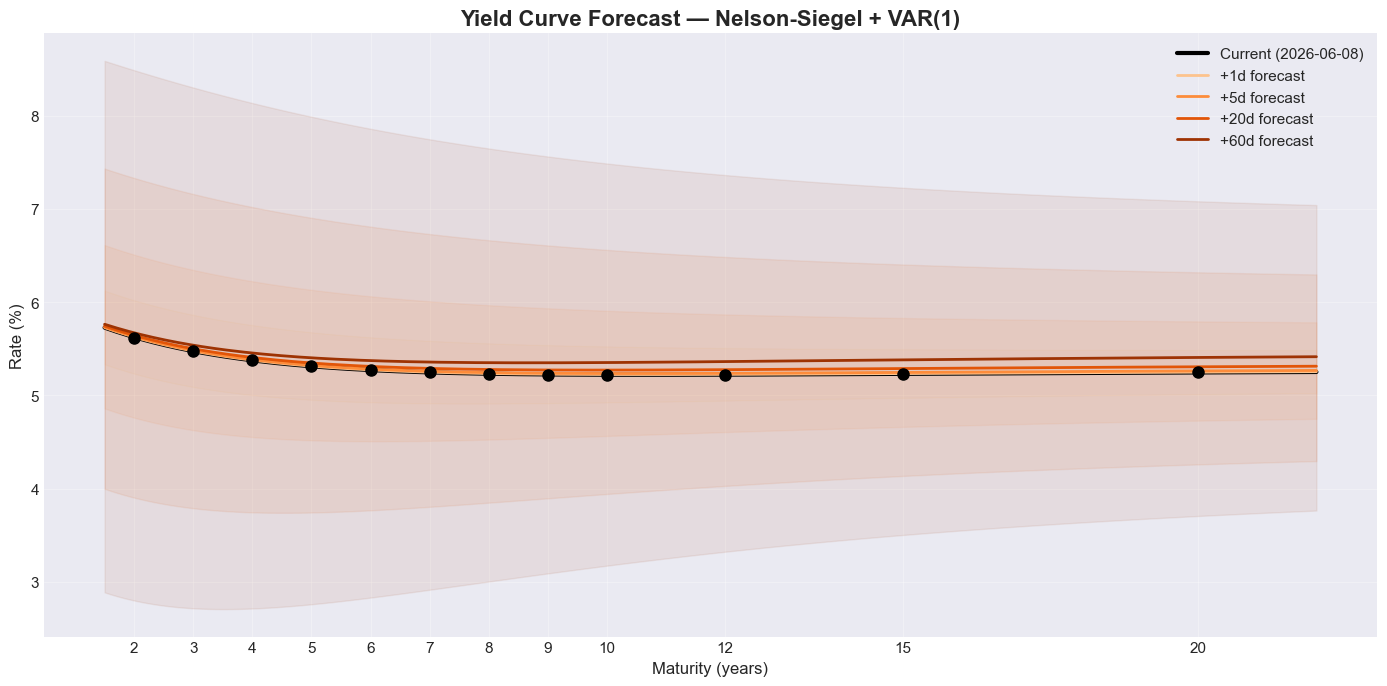


Yield Curve Forecast Table (selected tenors):
   Tenor   Current       +1d       +5d      +20d      +60d
------------------------------------------------------------
     2Y     5.625  5.626(+0.00)  5.630(+0.01)  5.644(+0.02)  5.671(+0.05)
     5Y     5.312  5.314(+0.00)  5.321(+0.01)  5.347(+0.04)  5.402(+0.09)
    10Y     5.221  5.224(+0.00)  5.234(+0.01)  5.271(+0.05)  5.352(+0.13)
    15Y     5.231  5.234(+0.00)  5.245(+0.01)  5.287(+0.06)  5.381(+0.15)
    20Y     5.246  5.249(+0.00)  5.262(+0.02)  5.306(+0.06)  5.406(+0.16)


In [13]:
# Reconstruct yield curve forecasts at specific horizons
horizons = [1, 5, 20, 60]  # business days
tau_curve = np.linspace(1.5, 22, 200)

fig, ax = plt.subplots(figsize=(14, 7))

# Current curve
current_curve = ns_curve(tau_curve, last_obs[0], last_obs[1], last_obs[2], LAM)
ax.plot(tau_curve, current_curve, 'k-', linewidth=3, label=f'Current ({last_date.strftime("%Y-%m-%d")})')

# Actual current data points
y_last = yield_matrix[-1]
valid_last = ~np.isnan(y_last)
ax.plot(maturities[valid_last], y_last[valid_last], 'ko', markersize=8, zorder=5)

# Forecast curves
cmap_fc = plt.cm.Oranges(np.linspace(0.3, 0.9, len(horizons)))
for j, h in enumerate(horizons):
    if h <= n_forecast:
        f = point_fcst[h-1]
        curve = ns_curve(tau_curve, f[0], f[1], f[2], LAM)
        ax.plot(tau_curve, curve, '-', color=cmap_fc[j], linewidth=2,
                label=f'+{h}d forecast')

        # Also show uncertainty band for this horizon
        f_lo = lower_fcst[h-1]
        f_hi = upper_fcst[h-1]
        curve_lo = ns_curve(tau_curve, f_lo[0], f_lo[1], f_lo[2], LAM)
        curve_hi = ns_curve(tau_curve, f_hi[0], f_hi[1], f_hi[2], LAM)
        ax.fill_between(tau_curve, curve_lo, curve_hi, alpha=0.08, color=cmap_fc[j])

ax.set_title('Yield Curve Forecast — Nelson-Siegel + VAR(1)', fontweight='bold', fontsize=16)
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Rate (%)')
ax.set_xticks([2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print forecast table
print(f"\nYield Curve Forecast Table (selected tenors):")
print(f"{'Tenor':>8s}  {'Current':>8s}", end='')
for h in horizons:
    print(f"  {f'+{h}d':>8s}", end='')
print()
print("-" * (10 + 10 + 10 * len(horizons)))

for t_idx, tenor in enumerate(maturities):
    if tenor in [2, 5, 10, 15, 20]:
        tau_t = float(tenor)
        current = ns_curve(np.array([tau_t]), last_obs[0], last_obs[1], last_obs[2], LAM)[0]
        print(f"{tenor:>6d}Y  {current:>8.3f}", end='')
        for h in horizons:
            f = point_fcst[h-1]
            fwd = ns_curve(np.array([tau_t]), f[0], f[1], f[2], LAM)[0]
            chg = fwd - current
            print(f"  {fwd:>5.3f}({chg:+.2f})", end='')
        print()

## 11. Export Results

In [14]:
# Save the factors
factors.to_pickle('ns_factors.pkl')
factors.to_csv('ns_factors.csv', index=False, encoding='utf-8-sig')
print(f"Saved ns_factors.pkl ({factors.shape[0]:,} rows)")
print(f"Saved ns_factors.csv")

# Save model parameters
import json
model_params = {
    'lambda': float(LAM),
    'var1_intercept': c_vec.tolist(),
    'var1_transition': A_mat.tolist(),
    'var1_sigma': sigma.tolist(),
    'long_run_means': long_run.tolist(),
    'estimation_date': str(last_date.date()),
    'n_observations': int(len(factors)),
}
with open('ns_model_params.json', 'w') as f:
    json.dump(model_params, f, indent=2)
print("Saved ns_model_params.json")

print(f"\n✅ Model summary:")
print(f"  λ = {LAM:.4f}")
print(f"  Average fit RMSE = {factors['rmse'].mean():.4f} pp")
print(f"  VAR(1) eigenvalues = {np.linalg.eigvals(A_mat).round(4)}")
print(f"  Last factors: β₁={last_obs[0]:.3f}, β₂={last_obs[1]:.3f}, β₃={last_obs[2]:.3f}")

Saved ns_factors.pkl (4,940 rows)
Saved ns_factors.csv
Saved ns_model_params.json

✅ Model summary:
  λ = 0.3709
  Average fit RMSE = 0.0467 pp
  VAR(1) eigenvalues = [0.9945 0.9995 0.998 ]
  Last factors: β₁=5.304, β₂=0.885, β₃=-1.325


## 📋 Summary

### What we built:
1. **Nelson-Siegel cross-sectional model** — fits each day's yield curve with 3 factors + λ
2. **Optimal λ** — selected via grid search to minimize average RMSE
3. **Factor time series** — β₁ (level), β₂ (slope), β₃ (curvature) over 2006–2026
4. **Diebold-Li VAR(1)** — dynamic model for the factor evolution
5. **Multi-step forecasts** — point + 90% confidence bands for factors and curves

### Key outputs:
- `ns_factors.pkl` / `.csv` — daily Nelson-Siegel factors
- `ns_model_params.json` — estimated model parameters (λ, VAR coefficients, covariance)

### Possible extensions:
- **VAR(p)** with more lags or exogenous variables (policy rate, inflation)
- **Regime-switching DNS** — different dynamics in calm vs. crisis periods  
- **GARCH errors** — capture volatility clustering in the factor innovations
- **Kalman filter** — joint estimation of measurement + state equations
- **Svensson extension** — add a 4th factor for better long-end fit

---
*Reference: Diebold, F.X. and Li, C. (2006), "Forecasting the term structure of government bond yields," Journal of Econometrics, 130(2), 337-364.*